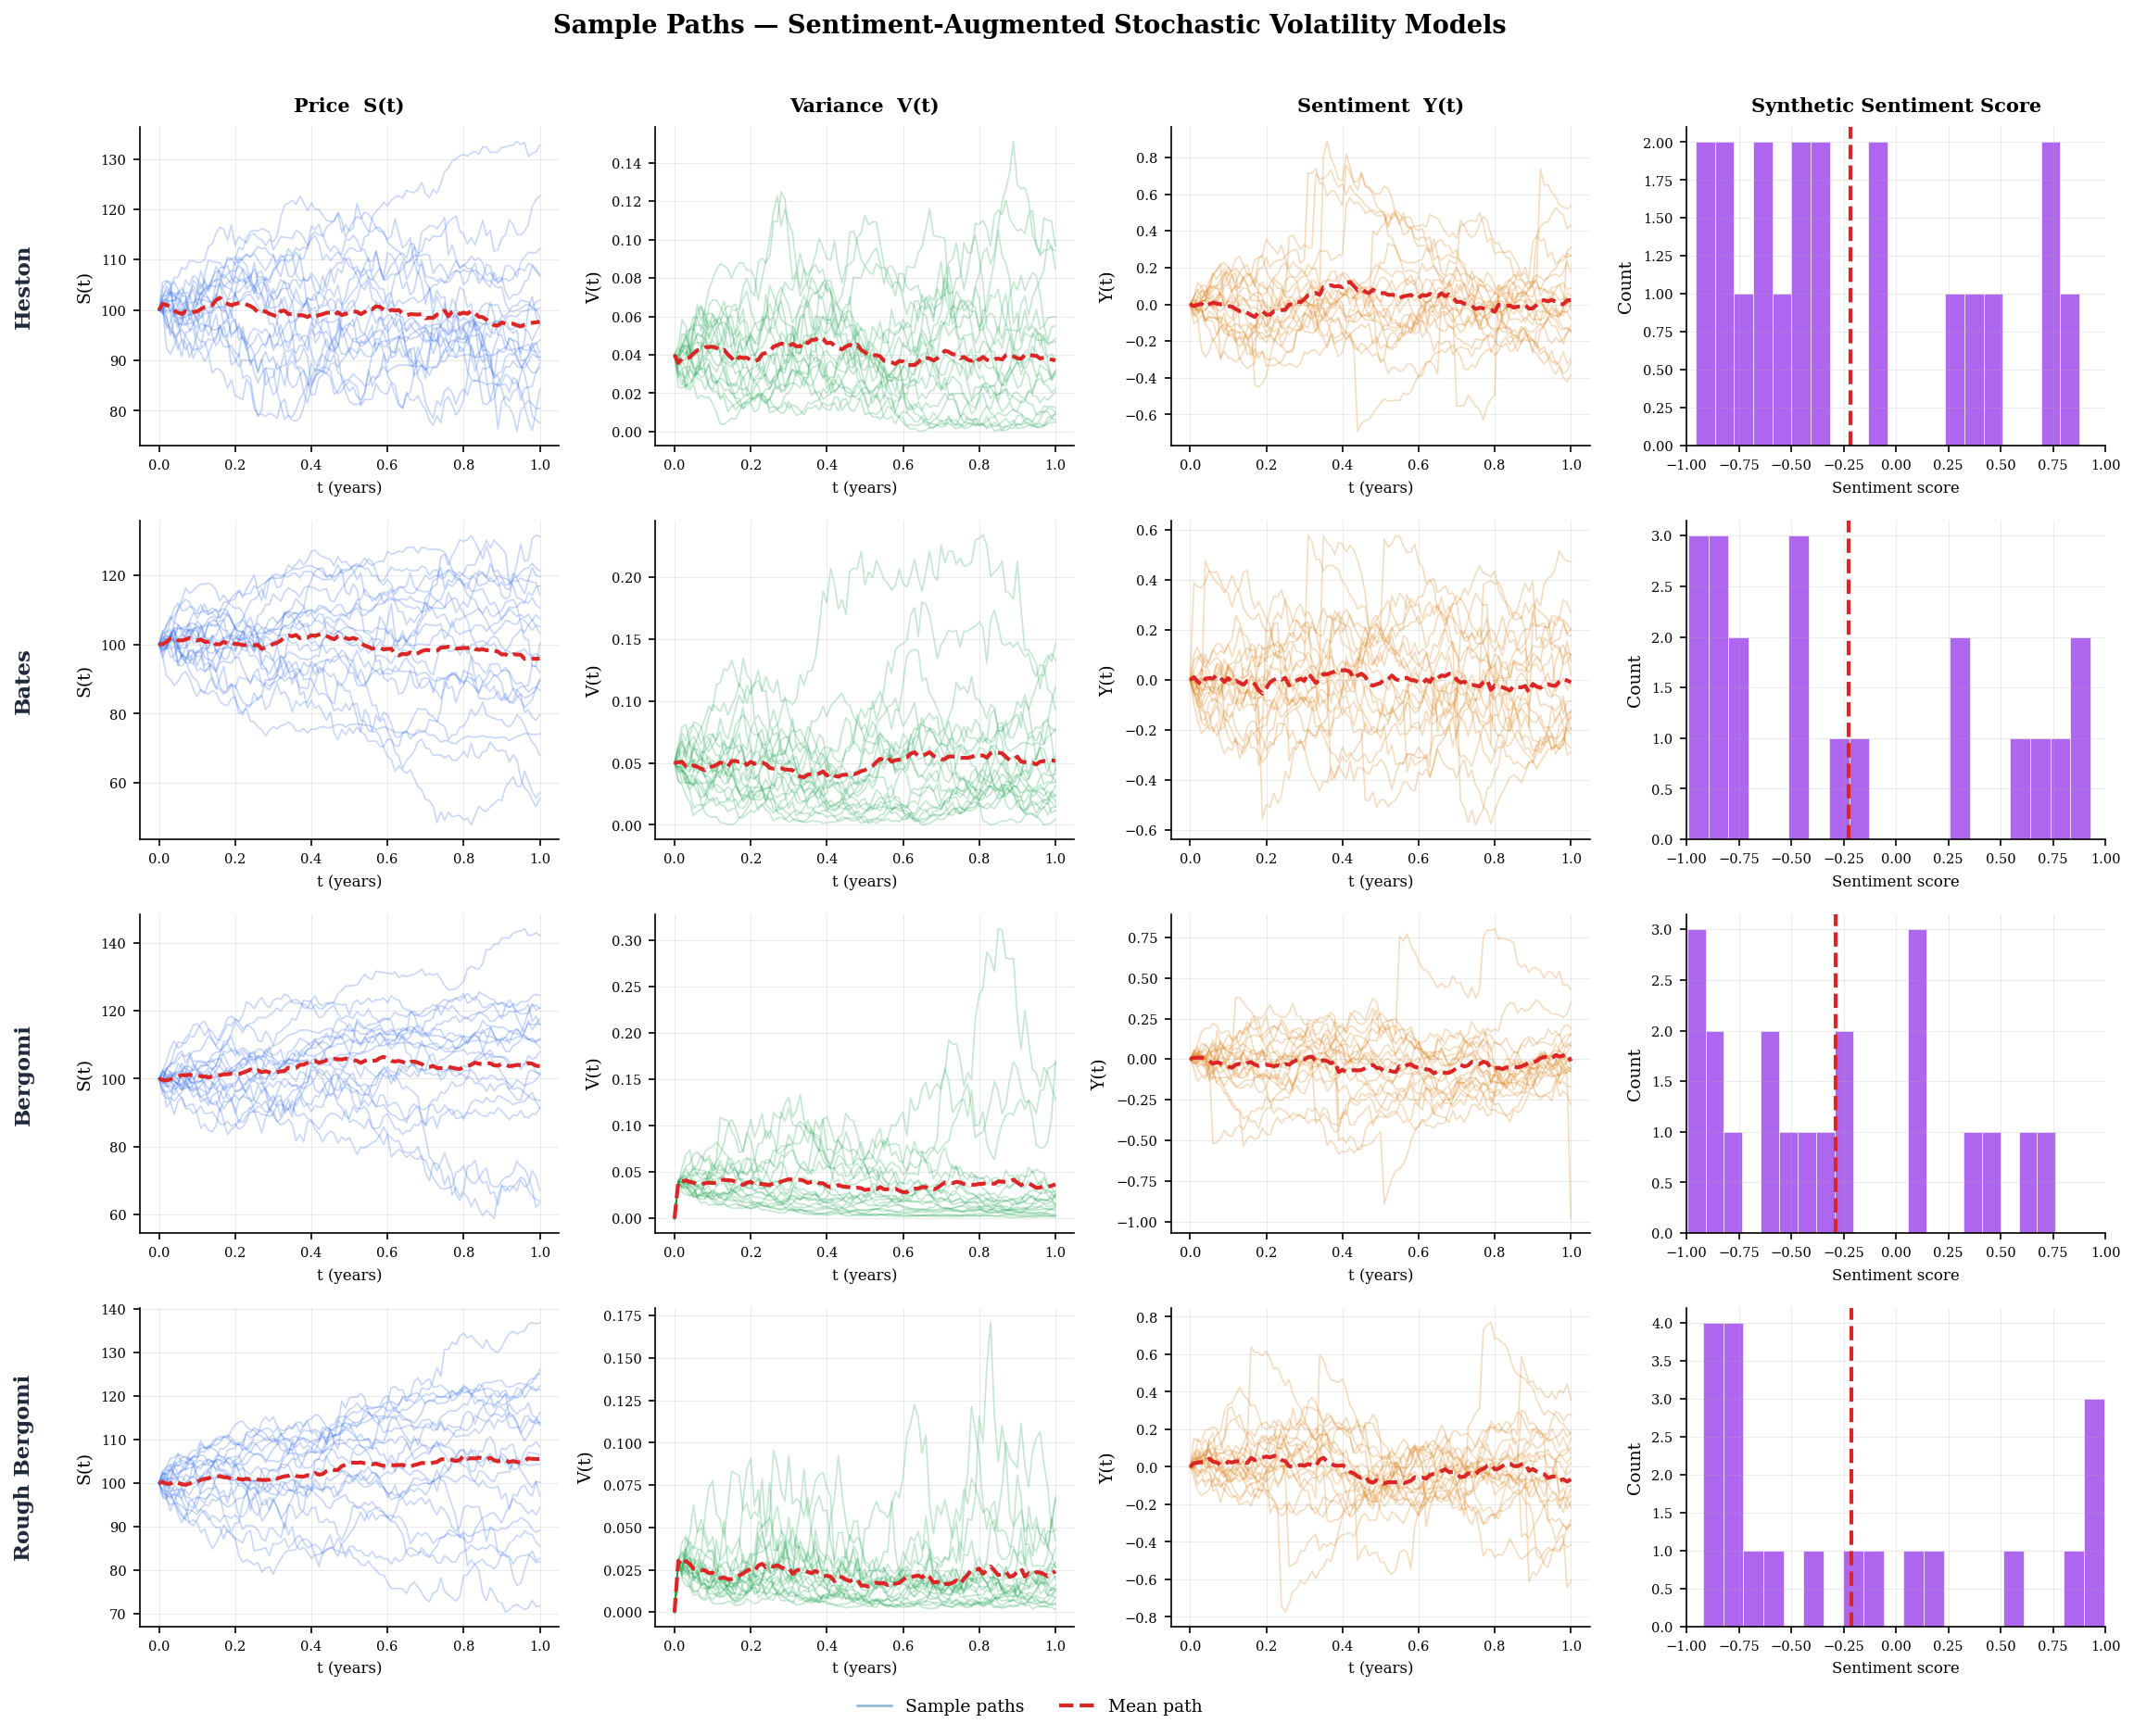

Saved to sample_paths.png


In [ ]:
import torch
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Simulation functions ────────────────────────────────────────────────────

def Sentiment_OU_Step(Y_t, Z_Y, dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device):
    jump_mask = (torch.rand_like(Y_t) < (lambd_Y * dt)).double()
    jump_sizes = (torch.randn_like(Y_t) * sigma_JY + mu_JY) * jump_mask
    dY = kappa_Y * (theta_Y - Y_t) * dt + sigma_Y * math.sqrt(dt) * Z_Y + jump_sizes
    return Y_t + dY


def Sentiment_Heston_Bates_MC_Batched(
    model_type, kappa, theta, sigma, v0, rho_SV, rho_SY,
    kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
    lambdJ, muJ, sigmaJ, T, K_strikes, S, r, q,
    N_paths=10000, N_steps=50, device='cpu'
):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = kappa.shape[0]

        kappa, theta, sigma, v0 = kappa.view(-1,1), theta.view(-1,1), sigma.view(-1,1), v0.view(-1,1)
        rho_SV, rho_SY = rho_SV.view(-1,1), rho_SY.view(-1,1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1,1), theta_Y.view(-1,1), sigma_Y.view(-1,1)
        lambd_Y, mu_JY, sigma_JY = lambd_Y.view(-1,1), mu_JY.view(-1,1), sigma_JY.view(-1,1)
        beta_S, beta_V = beta_S.view(-1,1), beta_V.view(-1,1)
        if model_type == 'Bates':
            lambdJ, muJ, sigmaJ = lambdJ.view(-1,1), muJ.view(-1,1), sigmaJ.view(-1,1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        Z_S = Z1
        Z_V = rho_SV.unsqueeze(-1) * Z1 + torch.sqrt(1 - rho_SV**2).unsqueeze(-1) * Z2
        Z_Y = rho_SY.unsqueeze(-1) * Z1 + torch.sqrt(1 - rho_SY**2).unsqueeze(-1) * Z3

        V_t   = v0.expand(num_samples, N_paths).clone()
        Y_t   = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        log_S_history[:, :, 0] = log_S
        V_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        V_history[:, :, 0] = V_t
        Y_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        Y_history[:, :, 0] = Y_t

        for t in range(N_steps):
            Y_t = Sentiment_OU_Step(Y_t, Z_Y[:,:,t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            if model_type == 'Bates':
                S_jump_mask  = (torch.rand_like(log_S) < (lambdJ * dt)).double()
                S_jump_sizes = (torch.randn_like(log_S) * sigmaJ + muJ) * S_jump_mask
            else:
                S_jump_sizes = 0.0

            V_next = V_t + kappa * (theta * torch.exp(beta_V * Y_t) - V_t) * dt \
                     + sigma * torch.sqrt(torch.clamp(V_t, min=0.0)) * math.sqrt(dt) * Z_V[:,:,t]
            V_t = torch.clamp(V_next, min=1e-8)
            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt \
                    + torch.sqrt(V_t) * math.sqrt(dt) * Z_S[:,:,t] + S_jump_sizes

            log_S_history[:, :, t+1] = log_S
            V_history[:, :, t+1]     = V_t
            Y_history[:, :, t+1]     = Y_t

        S_T = torch.exp(log_S)
        K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1,1,-1)
        payoffs   = torch.relu(S_T.unsqueeze(-1) - K_tensor)
        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)

        return CallPrices, log_S_history, V_history, Y_history


def Sentiment_Bergomi_MC_Batched(
    xi, nu, rho_SV, rho_SY, beta,
    kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
    T, K_strikes, S, r, q, N_paths=10000, N_steps=50, device='cpu'
):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = xi.shape[0]

        xi, nu   = xi.view(-1,1), nu.view(-1,1)
        rho_SV, rho_SY = rho_SV.view(-1,1), rho_SY.view(-1,1)
        beta     = beta.view(-1,1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1,1), theta_Y.view(-1,1), sigma_Y.view(-1,1)
        lambd_Y, mu_JY, sigma_JY  = lambd_Y.view(-1,1), mu_JY.view(-1,1), sigma_JY.view(-1,1)
        beta_S, beta_V = beta_S.view(-1,1), beta_V.view(-1,1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        rho_SV_exp = rho_SV.unsqueeze(-1)
        rho_SY_exp = rho_SY.unsqueeze(-1)

        dW_S = Z1 * math.sqrt(dt)
        dW_V = (rho_SV_exp * Z1 + torch.sqrt(1 - rho_SV_exp**2) * Z2) * math.sqrt(dt)
        Z_Y  = rho_SY_exp * Z1 + torch.sqrt(1 - rho_SY_exp**2) * Z3

        X     = torch.zeros(num_samples, N_paths, dtype=torch.float64, device=device)
        Y_t   = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        log_S_history[:,:,0] = log_S
        V_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        Y_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        Y_history[:,:,0] = Y_t

        for t in range(N_steps):
            t_val = (t+1) * dt
            Y_t   = Sentiment_OU_Step(Y_t, Z_Y[:,:,t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            E_X2  = (1 - torch.exp(-2 * beta * t_val)) / (2 * beta)
            V_t   = xi * torch.exp(nu * X - 0.5 * nu**2 * E_X2) * torch.exp(beta_V * Y_t)
            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt + torch.sqrt(V_t) * dW_S[:,:,t]
            X     = X - beta * X * dt + dW_V[:,:,t]

            log_S_history[:,:,t+1] = log_S
            V_history[:,:,t+1]     = V_t
            Y_history[:,:,t+1]     = Y_t

        S_T = torch.exp(log_S)
        K_tensor   = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1,1,-1)
        payoffs    = torch.relu(S_T.unsqueeze(-1) - K_tensor)
        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)

        return CallPrices, log_S_history, V_history, Y_history


def Sentiment_rBergomi_MC_Batched(
    xi, nu, rho_SV, rho_SY, H,
    kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
    T, K_strikes, S, r, q, N_paths=10000, N_steps=50, device='cpu'
):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = xi.shape[0]

        xi, nu   = xi.view(-1,1), nu.view(-1,1)
        rho_SV, rho_SY = rho_SV.view(-1,1), rho_SY.view(-1,1)
        H        = H.view(-1,1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1,1), theta_Y.view(-1,1), sigma_Y.view(-1,1)
        lambd_Y, mu_JY, sigma_JY  = lambd_Y.view(-1,1), mu_JY.view(-1,1), sigma_JY.view(-1,1)
        beta_S, beta_V = beta_S.view(-1,1), beta_V.view(-1,1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        rho_SV_exp = rho_SV.unsqueeze(-1)
        rho_SY_exp = rho_SY.unsqueeze(-1)

        dW_S = Z1 * math.sqrt(dt)
        dW_V = (rho_SV_exp * Z1 + torch.sqrt(1 - rho_SV_exp**2) * Z2) * math.sqrt(dt)
        Z_Y  = rho_SY_exp * Z1 + torch.sqrt(1 - rho_SY_exp**2) * Z3

        Y_t   = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        log_S_history[:,:,0] = log_S
        V_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        Y_history = torch.zeros((num_samples, N_paths, N_steps+1), dtype=torch.float64, device=device)
        Y_history[:,:,0] = Y_t

        for t in range(N_steps):
            t_val = (t+1) * dt
            Y_t   = Sentiment_OU_Step(Y_t, Z_Y[:,:,t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            if t == 0:
                Z_t = torch.zeros_like(log_S)
            else:
                s_vals = torch.arange(0, t, device=device, dtype=torch.float64) * dt
                kernel = (t_val - s_vals).view(1,1,-1) ** (H.unsqueeze(-1) - 0.5)
                Z_t    = torch.sum(kernel * dW_V[:,:,:t], dim=2)

            V_t   = xi * torch.exp(nu * math.sqrt(2) * torch.sqrt(H) * Z_t
                                   - 0.5 * nu**2 * (t_val ** (2*H))) * torch.exp(beta_V * Y_t)
            V_t   = torch.clamp(V_t, min=1e-8)
            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt + torch.sqrt(V_t) * dW_S[:,:,t]

            log_S_history[:,:,t+1] = log_S
            V_history[:,:,t+1]     = V_t
            Y_history[:,:,t+1]     = Y_t

        S_T = torch.exp(log_S)
        K_tensor   = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1,1,-1)
        payoffs    = torch.relu(S_T.unsqueeze(-1) - K_tensor)
        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)

        return CallPrices, log_S_history, V_history, Y_history


# ── Shared parameters ────────────────────────────────────────────────────────

device   = 'cpu'
N_PATHS  = 20        # paths to plot
N_STEPS  = 100
T        = 1.0
S0       = 100.0
r, q     = 0.05, 0.0
K_strikes = [90, 95, 100, 105, 110]

t_grid = np.linspace(0, T, N_STEPS + 1)

# Shared sentiment (OU-Jumps) parameters
ou = dict(
    kappa_Y=torch.tensor([3.0]),
    theta_Y=torch.tensor([0.0]),
    sigma_Y=torch.tensor([0.4]),
    lambd_Y=torch.tensor([2.0]),
    mu_JY  =torch.tensor([0.0]),
    sigma_JY=torch.tensor([0.3]),
    rho_SY =torch.tensor([-0.3]),
    beta_S =torch.tensor([0.15]),
    beta_V =torch.tensor([0.4]),
)

# ── Plot style ───────────────────────────────────────────────────────────────

COLORS = {
    'price': '#2563EB',   # blue
    'vol':   '#16A34A',   # green
    'sent':  '#D97706',   # amber
    'score': '#9333EA',   # purple
    'mean':  '#DC2626',   # red (mean line)
}
ALPHA_PATH = 0.25
LW_PATH    = 0.8
LW_MEAN    = 2.0

plt.rcParams.update({
    'font.family':     'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid':       True,
    'grid.alpha':      0.25,
    'grid.linewidth':  0.5,
    'figure.dpi':      150,
})

def compute_synthetic_sentiment(log_S_paths, T_val):
    with torch.no_grad():
        log_returns = log_S_paths[:, :, 1:] - log_S_paths[:, :, :-1]

        dt_sim    = T_val / (log_S_paths.shape[2] - 1)
        dt_day    = 1.0 / 252.0
        scale_mean = dt_day / dt_sim
        scale_vol  = math.sqrt(dt_day / dt_sim)

        max_steps = log_returns.shape[2]
        steps_1d  = max(1, min(max_steps, int(round(dt_day / dt_sim))))
        steps_5d  = max(1, min(max_steps, int(round((5.0  / 252.0) / dt_sim))))
        steps_21d = max(1, min(max_steps, int(round((21.0 / 252.0) / dt_sim))))

        rets_1d  = log_returns[:, :, -steps_1d:]
        rets_5d  = log_returns[:, :, -steps_5d:]
        rets_21d = log_returns[:, :, -steps_21d:]

        ret      = torch.sum(rets_1d, dim=2)
        ret_sq   = ret ** 2
        abs_ret  = torch.abs(ret)

        roll_mean_5  = torch.mean(rets_5d,  dim=2) * scale_mean
        roll_vol_5   = torch.std(rets_5d,   dim=2) * scale_vol
        roll_mean_21 = torch.mean(rets_21d, dim=2) * scale_mean
        roll_vol_21  = torch.std(rets_21d,  dim=2) * scale_vol
        realized_var_21 = torch.sum(rets_21d ** 2, dim=2)

        neg_rets     = torch.clamp(rets_21d, max=0.0)
        downside_21  = torch.sqrt(torch.mean(neg_rets ** 2, dim=2)) * scale_vol

        recent_prices = torch.exp(log_S_paths[:, :, -(steps_21d + 1):])
        rolling_max   = torch.cummax(recent_prices, dim=2)[0]
        drawdowns     = (recent_prices - rolling_max) / (rolling_max + 1e-8)
        drawdown_21   = torch.min(drawdowns, dim=2)[0]

        if (2 * steps_1d) <= max_steps:
            ret_lag1 = torch.sum(log_returns[:, :, -(2 * steps_1d):-steps_1d], dim=2)
        else:
            ret_lag1 = roll_mean_21
        z_lag1 = (ret_lag1 - roll_mean_21) / (roll_vol_21 + 1e-8)

        raw = (
            0.05647883057984480 +
            0.6641564659089710  * z_lag1 +
            -20.48295023735650  * ret +
            78.6141455275039    * ret_sq +
            -14.195738738748300 * abs_ret +
            5.858262576733930   * roll_mean_5 +
            -46.01039458019490  * roll_mean_21 +
            5.962328909451680   * roll_vol_5 +
            32.61406085334050   * roll_vol_21 +
            -42.44005468356580  * downside_21 +
            0.7732553439690270  * drawdown_21 +
            -66.77329029078020  * realized_var_21
        )

        return torch.tanh(raw)   # (num_samples, N_paths)  — scalar per path


def plot_model(ax_S, ax_V, ax_Y, ax_SC, log_S_hist, V_hist, Y_hist):
    """Plot price, variance, sentiment process, and synthetic sentiment score."""
    S_np  = torch.exp(log_S_hist[0]).numpy()   # (N_paths, N_steps+1)
    V_np  = V_hist[0].numpy()
    Y_np  = Y_hist[0].numpy()

    # synthetic sentiment: one scalar per path — plot as cross-sectional distribution
    scores = compute_synthetic_sentiment(log_S_hist, T).squeeze(0).numpy()  # (N_paths,)

    for arr, ax, col in [
        (S_np, ax_S, COLORS['price']),
        (V_np, ax_V, COLORS['vol']),
        (Y_np, ax_Y, COLORS['sent']),
    ]:
        for path in arr:
            ax.plot(t_grid, path, color=col, alpha=ALPHA_PATH, lw=LW_PATH)
        ax.plot(t_grid, arr.mean(axis=0), color=COLORS['mean'], lw=LW_MEAN, ls='--')

    # Score panel: histogram of per-path synthetic sentiment scores
    ax_SC.hist(scores, bins=20, color=COLORS['score'], alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_SC.axvline(scores.mean(), color=COLORS['mean'], lw=LW_MEAN, ls='--')
    ax_SC.set_xlim(-1, 1)

    ax_S.set_ylabel('S(t)',          fontsize=9)
    ax_V.set_ylabel('V(t)',          fontsize=9)
    ax_Y.set_ylabel('Y(t)',          fontsize=9)
    ax_SC.set_ylabel('Count',        fontsize=9)
    ax_SC.set_xlabel('Sentiment score', fontsize=8)

    for ax in [ax_S, ax_V, ax_Y]:
        ax.set_xlabel('t (years)', fontsize=8)
    for ax in [ax_S, ax_V, ax_Y, ax_SC]:
        ax.tick_params(labelsize=7)


# ── Run each model & plot ────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('Sample Paths — Sentiment-Augmented Stochastic Volatility Models',
             fontsize=13, fontweight='bold', y=1.01)

col_labels = ['Price  S(t)', 'Variance  V(t)', 'Sentiment  Y(t)', 'Synthetic Sentiment Score']
for j, lbl in enumerate(col_labels):
    axes[0, j].set_title(lbl, fontsize=10, fontweight='bold', pad=8)

row_labels = ['Heston', 'Bates', 'Bergomi', 'Rough Bergomi']
for i, lbl in enumerate(row_labels):
    axes[i, 0].set_ylabel('S(t)', fontsize=9)
    axes[i, 0].annotate(
        lbl, xy=(0, 0.5), xytext=(-60, 0),
        xycoords='axes fraction', textcoords='offset points',
        fontsize=11, fontweight='bold', va='center', ha='center',
        rotation=90, color='#1e293b',
    )

# ── 1. Heston ────────────────────────────────────────────────────────────────
_, log_S, V_h, Y_h = Sentiment_Heston_Bates_MC_Batched(
    model_type='Heston',
    kappa  =torch.tensor([2.0]),
    theta  =torch.tensor([0.04]),
    sigma  =torch.tensor([0.3]),
    v0     =torch.tensor([0.04]),
    rho_SV =torch.tensor([-0.7]),
    lambdJ =torch.tensor([0.0]),
    muJ    =torch.tensor([0.0]),
    sigmaJ =torch.tensor([0.0]),
    T=T, K_strikes=K_strikes, S=S0, r=r, q=q,
    N_paths=N_PATHS, N_steps=N_STEPS, device=device,
    **ou,
)
plot_model(*axes[0], log_S, V_h, Y_h)

# ── 2. Bates ─────────────────────────────────────────────────────────────────
_, log_S, V_b, Y_b = Sentiment_Heston_Bates_MC_Batched(
    model_type='Bates',
    kappa  =torch.tensor([1.5]),
    theta  =torch.tensor([0.05]),
    sigma  =torch.tensor([0.35]),
    v0     =torch.tensor([0.05]),
    rho_SV =torch.tensor([-0.6]),
    lambdJ =torch.tensor([0.3]),
    muJ    =torch.tensor([-0.05]),
    sigmaJ =torch.tensor([0.1]),
    T=T, K_strikes=K_strikes, S=S0, r=r, q=q,
    N_paths=N_PATHS, N_steps=N_STEPS, device=device,
    **ou,
)
plot_model(*axes[1], log_S, V_b, Y_b)

# ── 3. Bergomi ───────────────────────────────────────────────────────────────
_, log_S, V_bg, Y_bg = Sentiment_Bergomi_MC_Batched(
    xi    =torch.tensor([0.04]),
    nu    =torch.tensor([1.5]),
    rho_SV=torch.tensor([-0.7]),
    beta  =torch.tensor([0.5]),
    T=T, K_strikes=K_strikes, S=S0, r=r, q=q,
    N_paths=N_PATHS, N_steps=N_STEPS, device=device,
    **ou,
)
plot_model(*axes[2], log_S, V_bg, Y_bg)

# ── 4. Rough Bergomi ─────────────────────────────────────────────────────────
_, log_S, V_rb, Y_rb = Sentiment_rBergomi_MC_Batched(
    xi    =torch.tensor([0.04]),
    nu    =torch.tensor([1.2]),
    rho_SV=torch.tensor([-0.7]),
    H     =torch.tensor([0.1]),
    T=T, K_strikes=K_strikes, S=S0, r=r, q=q,
    N_paths=N_PATHS, N_steps=N_STEPS, device=device,
    **ou,
)
plot_model(*axes[3], log_S, V_rb, Y_rb)

# ── Legend & finishing touches ───────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='steelblue', alpha=0.6, lw=1.2, label='Sample paths'),
    Line2D([0],[0], color=COLORS['mean'], lw=2, ls='--', label='Mean path'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.savefig('/content/sample_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to sample_paths.png")